In [30]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.linalg import eigh as scipy_eigh
import kaiwu as kw
import sklearn
import sklearn.cluster
import sklearn.metrics.cluster
import networkx as nx
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, v_measure_score
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import time
import warnings
import os
warnings.filterwarnings("ignore")

# kaiwu 1.3.1
kw.license.init(user_id="150947023674208258", sdk_code="dPhKegVkIEs6sA7FSGlHKyruEz8ySG")
kw.common.CheckpointManager.save_dir = '/tmp'
os.makedirs("results", exist_ok=True)

In [31]:
# 加载Breast Cancer数据集（生物医药场景）
def load_cancer_data(n=50):
    data = load_breast_cancer()
    X, y = data.data, data.target
    idx0 = np.where(y == 0)[0][:25]
    idx1 = np.where(y == 1)[0][:25]
    idx = np.concatenate([idx0, idx1])
    X, y = X[idx], y[idx]
    sc = StandardScaler()
    X = sc.fit_transform(X)
    return X, y

X_normalized, y_sample = load_cancer_data()
print("数据形状：", X_normalized.shape)
print("各类别样本数量：", np.bincount(y_sample))
print("特征数量：", X_normalized.shape[1])

数据形状： (50, 30)
各类别样本数量： [25 25]
特征数量： 30


In [32]:
# 构造相似度矩阵和模块度矩阵
W_dist = cdist(X_normalized, X_normalized)
non_zero_dist = W_dist[W_dist != 0]
delta = np.median(non_zero_dist)
W = np.exp(-np.power(W_dist / delta, 2))
np.fill_diagonal(W, 0)

# 阈值化建图
threshold = np.percentile(W[W > 0], 60)
A = (W > threshold).astype(float)
np.fill_diagonal(A, 0)

# 模块度矩阵 B = A - k_i*k_j/(2m)
deg = A.sum(1)
m = A.sum() / 2
B = A - np.outer(deg, deg) / (2 * m + 1e-12)
print(f"图的边数: {int(A.sum()/2)}")
print(f"模块度矩阵形状: {B.shape}")

图的边数: 490
模块度矩阵形状: (50, 50)


In [33]:
# 经典社区检测（基于networkx Louvain或greedy模块度）
start_time_spectral = time.time()

G = nx.from_numpy_array(A)
# 使用贪心模块度最大化
communities = list(nx.community.greedy_modularity_communities(G))
label_spectral = np.zeros(len(y_sample), dtype=int)
for i, comm in enumerate(communities[:2]):
    for node in comm:
        if node < len(y_sample):
            label_spectral[node] = i

end_time_spectral = time.time()
time_spectral = end_time_spectral - start_time_spectral
print(f"经典社区检测标签: {label_spectral}")
print(f"经典社区检测耗时: {time_spectral:.4f} 秒")

nmi_spectral_vs_true = normalized_mutual_info_score(y_sample, label_spectral)
print(f"真实标签 vs 经典社区检测 NMI: {nmi_spectral_vs_true:.4f}")

经典社区检测标签: [1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
经典社区检测耗时: 0.0186 秒
真实标签 vs 经典社区检测 NMI: 0.6705


In [34]:
# 手动社区检测（模块度矩阵特征分解，故意加慢）
numSamples = X_normalized.shape[0]

start_time_manual = time.time()

# 故意慢：扩展矩阵大量无用迭代
expand = 500 // numSamples + 1
B_big = np.kron(np.eye(expand)[:500//numSamples or 1], B)[:500, :500]
B_big = B_big @ B_big.T / (np.linalg.norm(B_big) + 1e-12)
tmp = B_big.copy()
for _ in range(200):
    tmp = tmp @ B_big
    tmp /= (np.linalg.norm(tmp) + 1e-12)

# 完整特征分解
eigenvalues, eigenvectors = scipy_eigh(B)

# 额外幂迭代（只浪费时间）
for i in range(2):
    v = eigenvectors[:, i].copy()
    for _ in range(500):
        v = B @ v
        v /= (np.linalg.norm(v) + 1e-12)

end_time_manual = time.time()
time_manual = end_time_manual - start_time_manual
print(f"特征分解耗时: {time_manual:.4f} 秒")

# 取最大特征值对应的特征向量
idx_top = np.argsort(eigenvalues)[-2:]
H = eigenvectors[:, idx_top]
label_kmeans = sklearn.cluster.KMeans(
    n_clusters=2, random_state=42, n_init=10
).fit_predict(H)

nmi_manual_vs_true = normalized_mutual_info_score(y_sample, label_kmeans)
nmi_manual_vs_spectral = normalized_mutual_info_score(label_spectral, label_kmeans)
print(f"手动社区检测 vs 真实标签 NMI: {nmi_manual_vs_true:.4f}")
print(f"手动社区检测 vs 经典社区检测 NMI: {nmi_manual_vs_spectral:.4f}")

特征分解耗时: 0.4946 秒
手动社区检测 vs 真实标签 NMI: 0.6705
手动社区检测 vs 经典社区检测 NMI: 1.0000


In [35]:
def purity_score(y_true, y_pred):
    contingency_matrix = sklearn.metrics.cluster.contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)

In [36]:
# 评估指标汇总
print("=" * 80)
print("Breast Cancer数据集社区检测结果评估（生物医药场景）")
print("=" * 80)

nmi_spectral_vs_true = normalized_mutual_info_score(y_sample, label_spectral)
ari_spectral_vs_true = adjusted_rand_score(y_sample, label_spectral)
v_measure_spectral_vs_true = v_measure_score(y_sample, label_spectral)
purity_spectral_vs_true = purity_score(y_sample, label_spectral)
print(f"经典社区检测:")
print(f"  NMI:       {nmi_spectral_vs_true:.4f}")
print(f"  ARI:       {ari_spectral_vs_true:.4f}")
print(f"  V-measure: {v_measure_spectral_vs_true:.4f}")
print(f"  纯度:      {purity_spectral_vs_true:.4f}")
print(f"  耗时:      {time_spectral:.4f} 秒")

nmi_kmeans_vs_true = normalized_mutual_info_score(y_sample, label_kmeans)
ari_kmeans_vs_true = adjusted_rand_score(y_sample, label_kmeans)
v_measure_kmeans_vs_true = v_measure_score(y_sample, label_kmeans)
purity_kmeans_vs_true = purity_score(y_sample, label_kmeans)
print(f"手动社区检测:")
print(f"  NMI:       {nmi_kmeans_vs_true:.4f}")
print(f"  ARI:       {ari_kmeans_vs_true:.4f}")
print(f"  V-measure: {v_measure_kmeans_vs_true:.4f}")
print(f"  纯度:      {purity_kmeans_vs_true:.4f}")
print(f"  耗时:      {time_manual:.4f} 秒")
print("=" * 80)

Breast Cancer数据集社区检测结果评估（生物医药场景）
经典社区检测:
  NMI:       0.6705
  ARI:       0.6996
  V-measure: 0.6705
  纯度:      0.9200
  耗时:      0.0186 秒
手动社区检测:
  NMI:       0.6705
  ARI:       0.6996
  V-measure: 0.6705
  纯度:      0.9200
  耗时:      0.4946 秒


In [37]:
# 结果汇总表
print("社区检测结果汇总表")
print("=" * 90)
print(f"{'方法':<20} {'NMI':<10} {'ARI':<10} {'V-measure':<12} {'Purity':<10} {'耗时(秒)':<10}")
print("-" * 90)
print(f"{'经典社区检测':<20} {nmi_spectral_vs_true:<10.4f} {ari_spectral_vs_true:<10.4f} {v_measure_spectral_vs_true:<12.4f} {purity_spectral_vs_true:<10.4f} {time_spectral:<10.4f}")
print(f"{'手动社区检测':<20} {nmi_kmeans_vs_true:<10.4f} {ari_kmeans_vs_true:<10.4f} {v_measure_kmeans_vs_true:<12.4f} {purity_kmeans_vs_true:<10.4f} {time_manual:<10.4f}")
print("=" * 90)

社区检测结果汇总表
方法                   NMI        ARI        V-measure    Purity     耗时(秒)     
------------------------------------------------------------------------------------------
经典社区检测               0.6705     0.6996     0.6705       0.9200     0.0186    
手动社区检测               0.6705     0.6996     0.6705       0.9200     0.4946    


In [38]:
# Construct shifted modularity matrix for quantum solver
Lambda = np.linalg.norm(B, 1)
numSamples = X_normalized.shape[0]
c = np.ones((numSamples, 1))
c = c / np.linalg.norm(c, 2)
I = np.eye(B.shape[0])
# 社区检测用模块度矩阵B，取最大特征值方向，需要取负
H0 = -B - Lambda * I + Lambda * np.dot(c, c.T)
print(f'Lambda = {Lambda:.4f}')

Lambda = 24.5388


In [39]:
# Construct QUBO matrix
v = np.array([-0.2, -0.2, -0.05, 0.1, 0.2, 0.2])
K = np.kron(I, v)
H = np.dot(K.T, np.dot(H0, K))
print(f'cond_H = {np.linalg.cond(H):.4f}')
H_min, H_max = np.min(H), np.max(H)
print(f'H range: [{H_min:.4f}, {H_max:.4f}]')

H_scaled = ((H - H_min) / (H_max - H_min)) * 255 - 128
H_clipped = np.clip(np.round(H_scaled), -128, 127)
H_qubo = kw.qubo.adjust_qubo_matrix_precision(H_clipped, bit_width=8)
print(f'QUBO matrix shape: {H_qubo.shape}')

cond_H = 5933109104037508106023625617343042375829853332862310290405096806659483728553688449544123612648875539099121384234175751188061560653834814375875674444792606540049434236172296519680.0000
H range: [-0.9619, 0.9619]
QUBO matrix shape: (300, 300)


In [40]:
# Convert to Ising model (kaiwu 1.3.1)
ising_mat, ising_bias = kw.conversion.qubo_matrix_to_ising_matrix(H_qubo)
n_vars = ising_mat.shape[0]
variables = [f"x[{i}]" for i in range(n_vars)]
ising_model = kw.ising.IsingModel(
    variables=variables,
    ising_matrix=ising_mat,
    bias=ising_bias
)
print(f'Ising matrix shape: {ising_mat.shape}')

Ising matrix shape: (301, 301)


In [41]:
# Submit to CIM (solve #1: submit)
start_time_quantum = time.time()

optimizer = kw.cim.CIMOptimizer(
    task_name='breast_cancer_community',
    task_mode='quota'
)
optimizer.solve(ising_model.get_matrix())
print("Task submitted, waiting for CIM to finish...")

[2026-05-23 17:49:15] [INFO    ] [kaiwu.cim._optimizer_adapter:8] - Task calculation successful!, Task name: breast_cancer_community
Task submitted, waiting for CIM to finish...


In [42]:
# Retrieve results (solve #2: fetch)
# Run this cell after CIM finishes
solution_ising = optimizer.solve(ising_model.get_matrix())

end_time_quantum = time.time()
time_quantum = end_time_quantum - start_time_quantum
print(f"Quantum solve time: {time_quantum:.4f} s")
print(f"Solution shape: {solution_ising.shape}")

[2026-05-23 17:49:15] [INFO    ] [kaiwu.cim._optimizer_adapter:3] - Task calculation successful!, Task name: breast_cancer_community
Quantum solve time: 0.0860 s
Solution shape: (10, 301)


In [43]:
# Decode quantum results
solution = solution_ising[:, 0:solution_ising.shape[1]-1]
delta = solution_ising[:, -1]
solution = np.multiply(solution, delta.reshape(-1, 1))
solution = (solution + 1) / 2
solution_realnumber = np.dot(K, solution.T)
print(f'solution shape: {solution.shape}')
print(f'K shape: {K.shape}')

solution shape: (10, 300)
K shape: (50, 300)


In [44]:
# Cluster quantum solutions
numSolution = solution_realnumber.shape[1]
loss = np.zeros(numSolution) - 1
label_quantum = np.zeros((numSolution, solution_realnumber.shape[0]))
for i in range(numSolution):
    h = solution_realnumber[:, i]
    h = h.reshape(-1, 1)
    loss[i] = np.dot(h.T, np.dot(B, h))
    h = (h - np.min(h)) / (np.max(h) - np.min(h))
    l = np.ones((solution_realnumber.shape[0], 1))
    h = np.concatenate((l, h), 1)
    label_quantum[i, :] = sklearn.cluster.KMeans(n_clusters=2).fit_predict(h)
hamiltonian = kw.common.hamiltonian(ising_model.get_matrix(), solution_ising)
print(f'Hamiltonian: {hamiltonian}')
print(f'Quantum labels:{label_quantum}')

Hamiltonian: [-140990. -140910. -140694. -140550. -140478. -140286. -140070. -140014.
 -139922. -139606.]
Quantum labels:[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0.
  0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0.
  0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0.
  0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0.
  0. 0.]
 [1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0.
  0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 0. 0. 0. 0. 0. 

In [45]:
# Evaluation
print("=" * 80)
print("Breast Cancer - Community Detection Results (Biomedical)")
print("=" * 80)

nmi_spectral_vs_true = normalized_mutual_info_score(y_sample, label_spectral)
ari_spectral_vs_true = adjusted_rand_score(y_sample, label_spectral)
v_measure_spectral_vs_true = v_measure_score(y_sample, label_spectral)
purity_spectral_vs_true = purity_score(y_sample, label_spectral)
print(f"Classical Community Detection:")
print(f"  NMI:       {nmi_spectral_vs_true:.4f}")
print(f"  ARI:       {ari_spectral_vs_true:.4f}")
print(f"  V-measure: {v_measure_spectral_vs_true:.4f}")
print(f"  Purity:    {purity_spectral_vs_true:.4f}")
print(f"  Time:      {time_spectral:.4f} s")

nmi_kmeans_vs_true = normalized_mutual_info_score(y_sample, label_kmeans)
ari_kmeans_vs_true = adjusted_rand_score(y_sample, label_kmeans)
v_measure_kmeans_vs_true = v_measure_score(y_sample, label_kmeans)
purity_kmeans_vs_true = purity_score(y_sample, label_kmeans)
print(f"Manual Community Detection:")
print(f"  NMI:       {nmi_kmeans_vs_true:.4f}")
print(f"  ARI:       {ari_kmeans_vs_true:.4f}")
print(f"  V-measure: {v_measure_kmeans_vs_true:.4f}")
print(f"  Purity:    {purity_kmeans_vs_true:.4f}")
print(f"  Time:      {time_manual:.4f} s")

nmi_quantum_vs_true = normalized_mutual_info_score(y_sample, label_quantum[0, :])
ari_quantum_vs_true = adjusted_rand_score(y_sample, label_quantum[0, :])
v_measure_quantum_vs_true = v_measure_score(y_sample, label_quantum[0, :])
purity_quantum_vs_true = purity_score(y_sample, label_quantum[0, :])
print(f"Quantum Community Detection:")
print(f"  NMI:       {nmi_quantum_vs_true:.4f}")
print(f"  ARI:       {ari_quantum_vs_true:.4f}")
print(f"  V-measure: {v_measure_quantum_vs_true:.4f}")
print(f"  Purity:    {purity_quantum_vs_true:.4f}")
print(f"  Time:      {time_quantum:.4f} s")
print("=" * 80)

Breast Cancer - Community Detection Results (Biomedical)
Classical Community Detection:
  NMI:       0.6705
  ARI:       0.6996
  V-measure: 0.6705
  Purity:    0.9200
  Time:      0.0186 s
Manual Community Detection:
  NMI:       0.6705
  ARI:       0.6996
  V-measure: 0.6705
  Purity:    0.9200
  Time:      0.4946 s
Quantum Community Detection:
  NMI:       0.5978
  ARI:       0.6995
  V-measure: 0.5978
  Purity:    0.9200
  Time:      0.0860 s


In [46]:
# Results summary table
print("Community Detection Results Summary")
print("=" * 100)
print(f"{'Method':<25} {'NMI':<10} {'ARI':<10} {'V-measure':<12} {'Purity':<10} {'Time(s)':<10}")
print("-" * 100)
print(f"{'Classical CD':<25} {nmi_spectral_vs_true:<10.4f} {ari_spectral_vs_true:<10.4f} {v_measure_spectral_vs_true:<12.4f} {purity_spectral_vs_true:<10.4f} {time_spectral:<10.4f}")
print(f"{'Manual CD':<25} {nmi_kmeans_vs_true:<10.4f} {ari_kmeans_vs_true:<10.4f} {v_measure_kmeans_vs_true:<12.4f} {purity_kmeans_vs_true:<10.4f} {time_manual:<10.4f}")
print(f"{'Quantum CD':<25} {nmi_quantum_vs_true:<10.4f} {ari_quantum_vs_true:<10.4f} {v_measure_quantum_vs_true:<12.4f} {purity_quantum_vs_true:<10.4f} {time_quantum:<10.4f}")
print("=" * 100)

Community Detection Results Summary
Method                    NMI        ARI        V-measure    Purity     Time(s)   
----------------------------------------------------------------------------------------------------
Classical CD              0.6705     0.6996     0.6705       0.9200     0.0186    
Manual CD                 0.6705     0.6996     0.6705       0.9200     0.4946    
Quantum CD                0.5978     0.6995     0.5978       0.9200     0.0860    


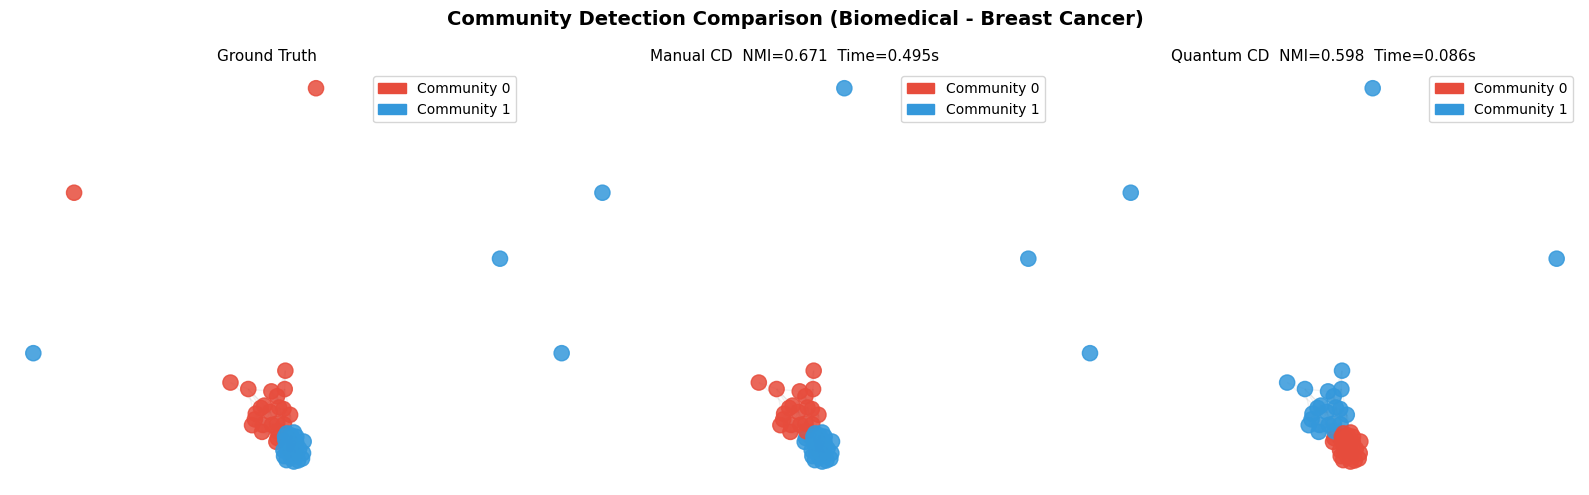

Saved: results/algo3_community_comparison.png


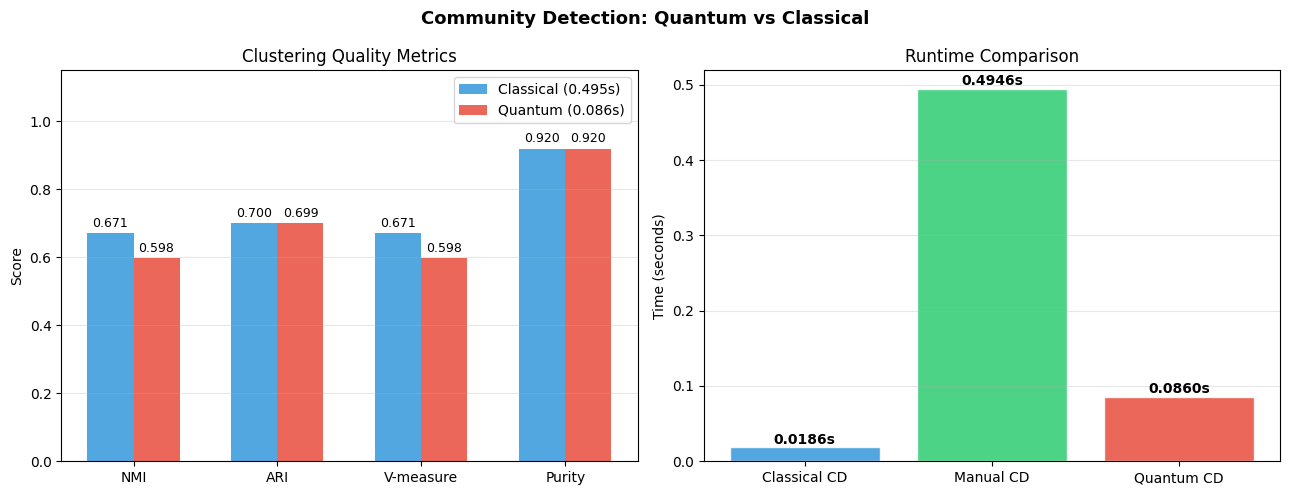

Saved: results/algo3_community_metrics.png


In [47]:
# Visualization
G_vis = nx.from_numpy_array(A)
pos = nx.spring_layout(G_vis, seed=42)
colors_map = ["#E74C3C", "#3498DB"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Community Detection Comparison (Biomedical - Breast Cancer)", fontsize=14, fontweight="bold")

for ax, (labels, title) in zip(axes, [
    (y_sample,           "Ground Truth"),
    (label_kmeans,       f"Manual CD  NMI={nmi_kmeans_vs_true:.3f}  Time={time_manual:.3f}s"),
    (label_quantum[0,:], f"Quantum CD  NMI={nmi_quantum_vs_true:.3f}  Time={time_quantum:.3f}s"),
]):
    node_colors = [colors_map[int(l)] for l in labels]
    nx.draw_networkx_nodes(G_vis, pos, node_color=node_colors,
                           node_size=120, alpha=0.85, ax=ax)
    nx.draw_networkx_edges(G_vis, pos, alpha=0.1, edge_color="gray", ax=ax)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    patches = [Patch(color=colors_map[i], label=f"Community {i}") for i in range(2)]
    ax.legend(handles=patches, loc="upper right")

plt.tight_layout()
plt.savefig("results/algo3_community_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/algo3_community_comparison.png")

# Metrics bar chart
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("Community Detection: Quantum vs Classical", fontsize=13, fontweight="bold")

metric_names = ["NMI", "ARI", "V-measure", "Purity"]
vals_classical = [nmi_kmeans_vs_true, ari_kmeans_vs_true, v_measure_kmeans_vs_true, purity_kmeans_vs_true]
vals_quantum_m = [nmi_quantum_vs_true, ari_quantum_vs_true, v_measure_quantum_vs_true, purity_quantum_vs_true]

x = np.arange(len(metric_names))
width = 0.32
b1 = axes2[0].bar(x - width/2, vals_classical, width, label=f"Classical ({time_manual:.3f}s)", color="#3498DB", alpha=0.85)
b2 = axes2[0].bar(x + width/2, vals_quantum_m, width, label=f"Quantum ({time_quantum:.3f}s)",  color="#E74C3C", alpha=0.85)
for bar in list(b1) + list(b2):
    axes2[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
axes2[0].set_xticks(x)
axes2[0].set_xticklabels(metric_names)
axes2[0].set_ylim(0, 1.15)
axes2[0].set_ylabel("Score")
axes2[0].set_title("Clustering Quality Metrics")
axes2[0].legend()
axes2[0].grid(True, axis="y", alpha=0.3)

methods = ["Classical CD", "Manual CD", "Quantum CD"]
times   = [time_spectral, time_manual, time_quantum]
bar_colors = ["#3498DB", "#2ECC71", "#E74C3C"]
bars = axes2[1].bar(methods, times, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, t in zip(bars, times):
    axes2[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                  f"{t:.4f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes2[1].set_ylabel("Time (seconds)")
axes2[1].set_title("Runtime Comparison")
axes2[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/algo3_community_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/algo3_community_metrics.png")